<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/10_report_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# NOTEBOOK 10: Generate All Report Figures
# ============================================

# ============================================
# CELL 1: Setup and Mount Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# Reset print function
import builtins
print = builtins.print

import numpy as np
import pandas as pd
import joblib
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("=" * 60)
print("✅ REPORT FIGURES NOTEBOOK")
print("=" * 60)

Mounted at /content/drive
✅ REPORT FIGURES NOTEBOOK


In [2]:
# ============================================
# CELL 2: Load All Saved Results
# ============================================
print("\n📂 Loading all results...")

# Load model comparison
model_comparison = pd.read_csv('/content/drive/MyDrive/xai-ids/results/metrics/model_comparison.csv')
print("✅ Model comparison loaded")

# Load XAI comparison
xai_comparison = pd.read_csv('/content/drive/MyDrive/xai-ids/results/metrics/xai_comparison.csv')
print("✅ XAI comparison loaded")

# Load dataset comparison
dataset_comparison = pd.read_csv('/content/drive/MyDrive/xai-ids/results/metrics/dataset_comparison.csv')
print("✅ Dataset comparison loaded")

# Load SHAP values
with open('/content/drive/MyDrive/xai-ids/results/shap_values.pkl', 'rb') as f:
    shap_data = pickle.load(f)
print("✅ SHAP values loaded")

# Load model and data for predictions
rf_model = joblib.load('/content/drive/MyDrive/xai-ids/results/models/random_forest.pkl')
data_path = '/content/drive/MyDrive/xai-ids/data/processed/nsl_kdd_processed.pkl'
data = joblib.load(data_path)
X_test = data['X_test']
y_test = data['y_test']
print("✅ Model and test data loaded")

print("\n📊 All data loaded successfully!")


📂 Loading all results...
✅ Model comparison loaded
✅ XAI comparison loaded
✅ Dataset comparison loaded
✅ SHAP values loaded
✅ Model and test data loaded

📊 All data loaded successfully!



📊 Generating Figure 1: Model Performance Comparison...


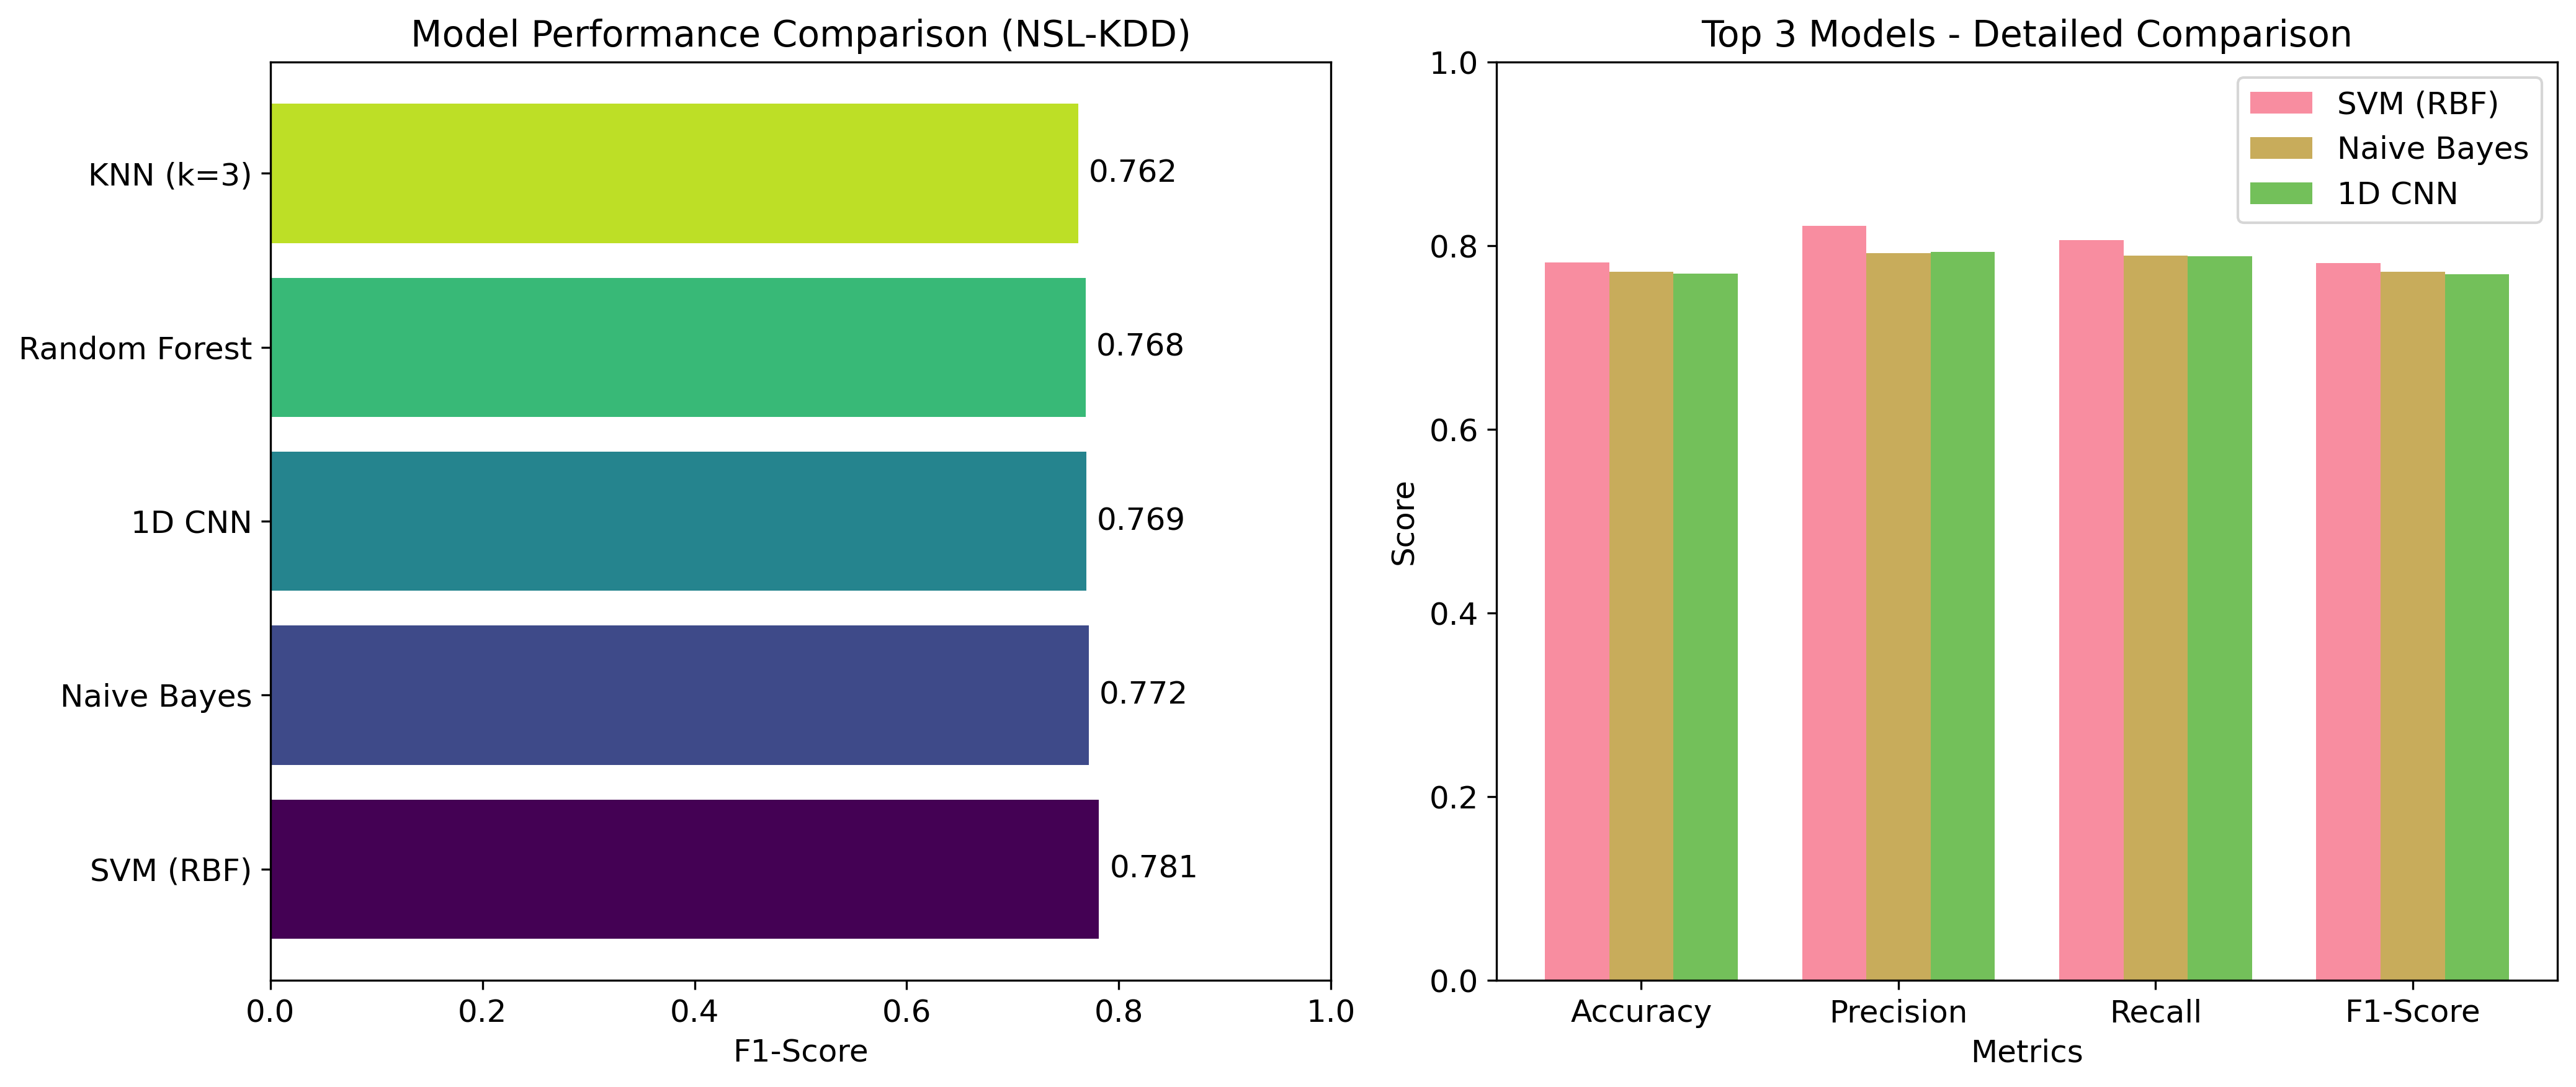

✅ Figure 1 saved!


In [3]:
# ============================================
# CELL 3: Figure 1 - Model Performance Comparison
# ============================================
print("\n📊 Generating Figure 1: Model Performance Comparison...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Bar chart of all models
models = model_comparison['model'].values
f1_scores = model_comparison['test_f1'].values

colors = plt.cm.viridis(np.linspace(0, 0.9, len(models)))
bars = axes[0].barh(models, f1_scores, color=colors)
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Model Performance Comparison (NSL-KDD)')
axes[0].set_xlim(0, 1)

# Add value labels
for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    axes[0].text(score + 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center')

# Plot 2: Metrics comparison for top 3 models
top_3 = model_comparison.nlargest(3, 'test_f1')
metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
x = np.arange(len(metrics))
width = 0.25

for i, (idx, row) in enumerate(top_3.iterrows()):
    values = [row[m] for m in metrics]
    axes[1].bar(x + i*width, values, width, label=row['model'], alpha=0.8)

axes[1].set_xlabel('Metrics')
axes[1].set_ylabel('Score')
axes[1].set_title('Top 3 Models - Detailed Comparison')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/report_fig1_model_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved!")


📊 Generating Figure 2: Confusion Matrix...


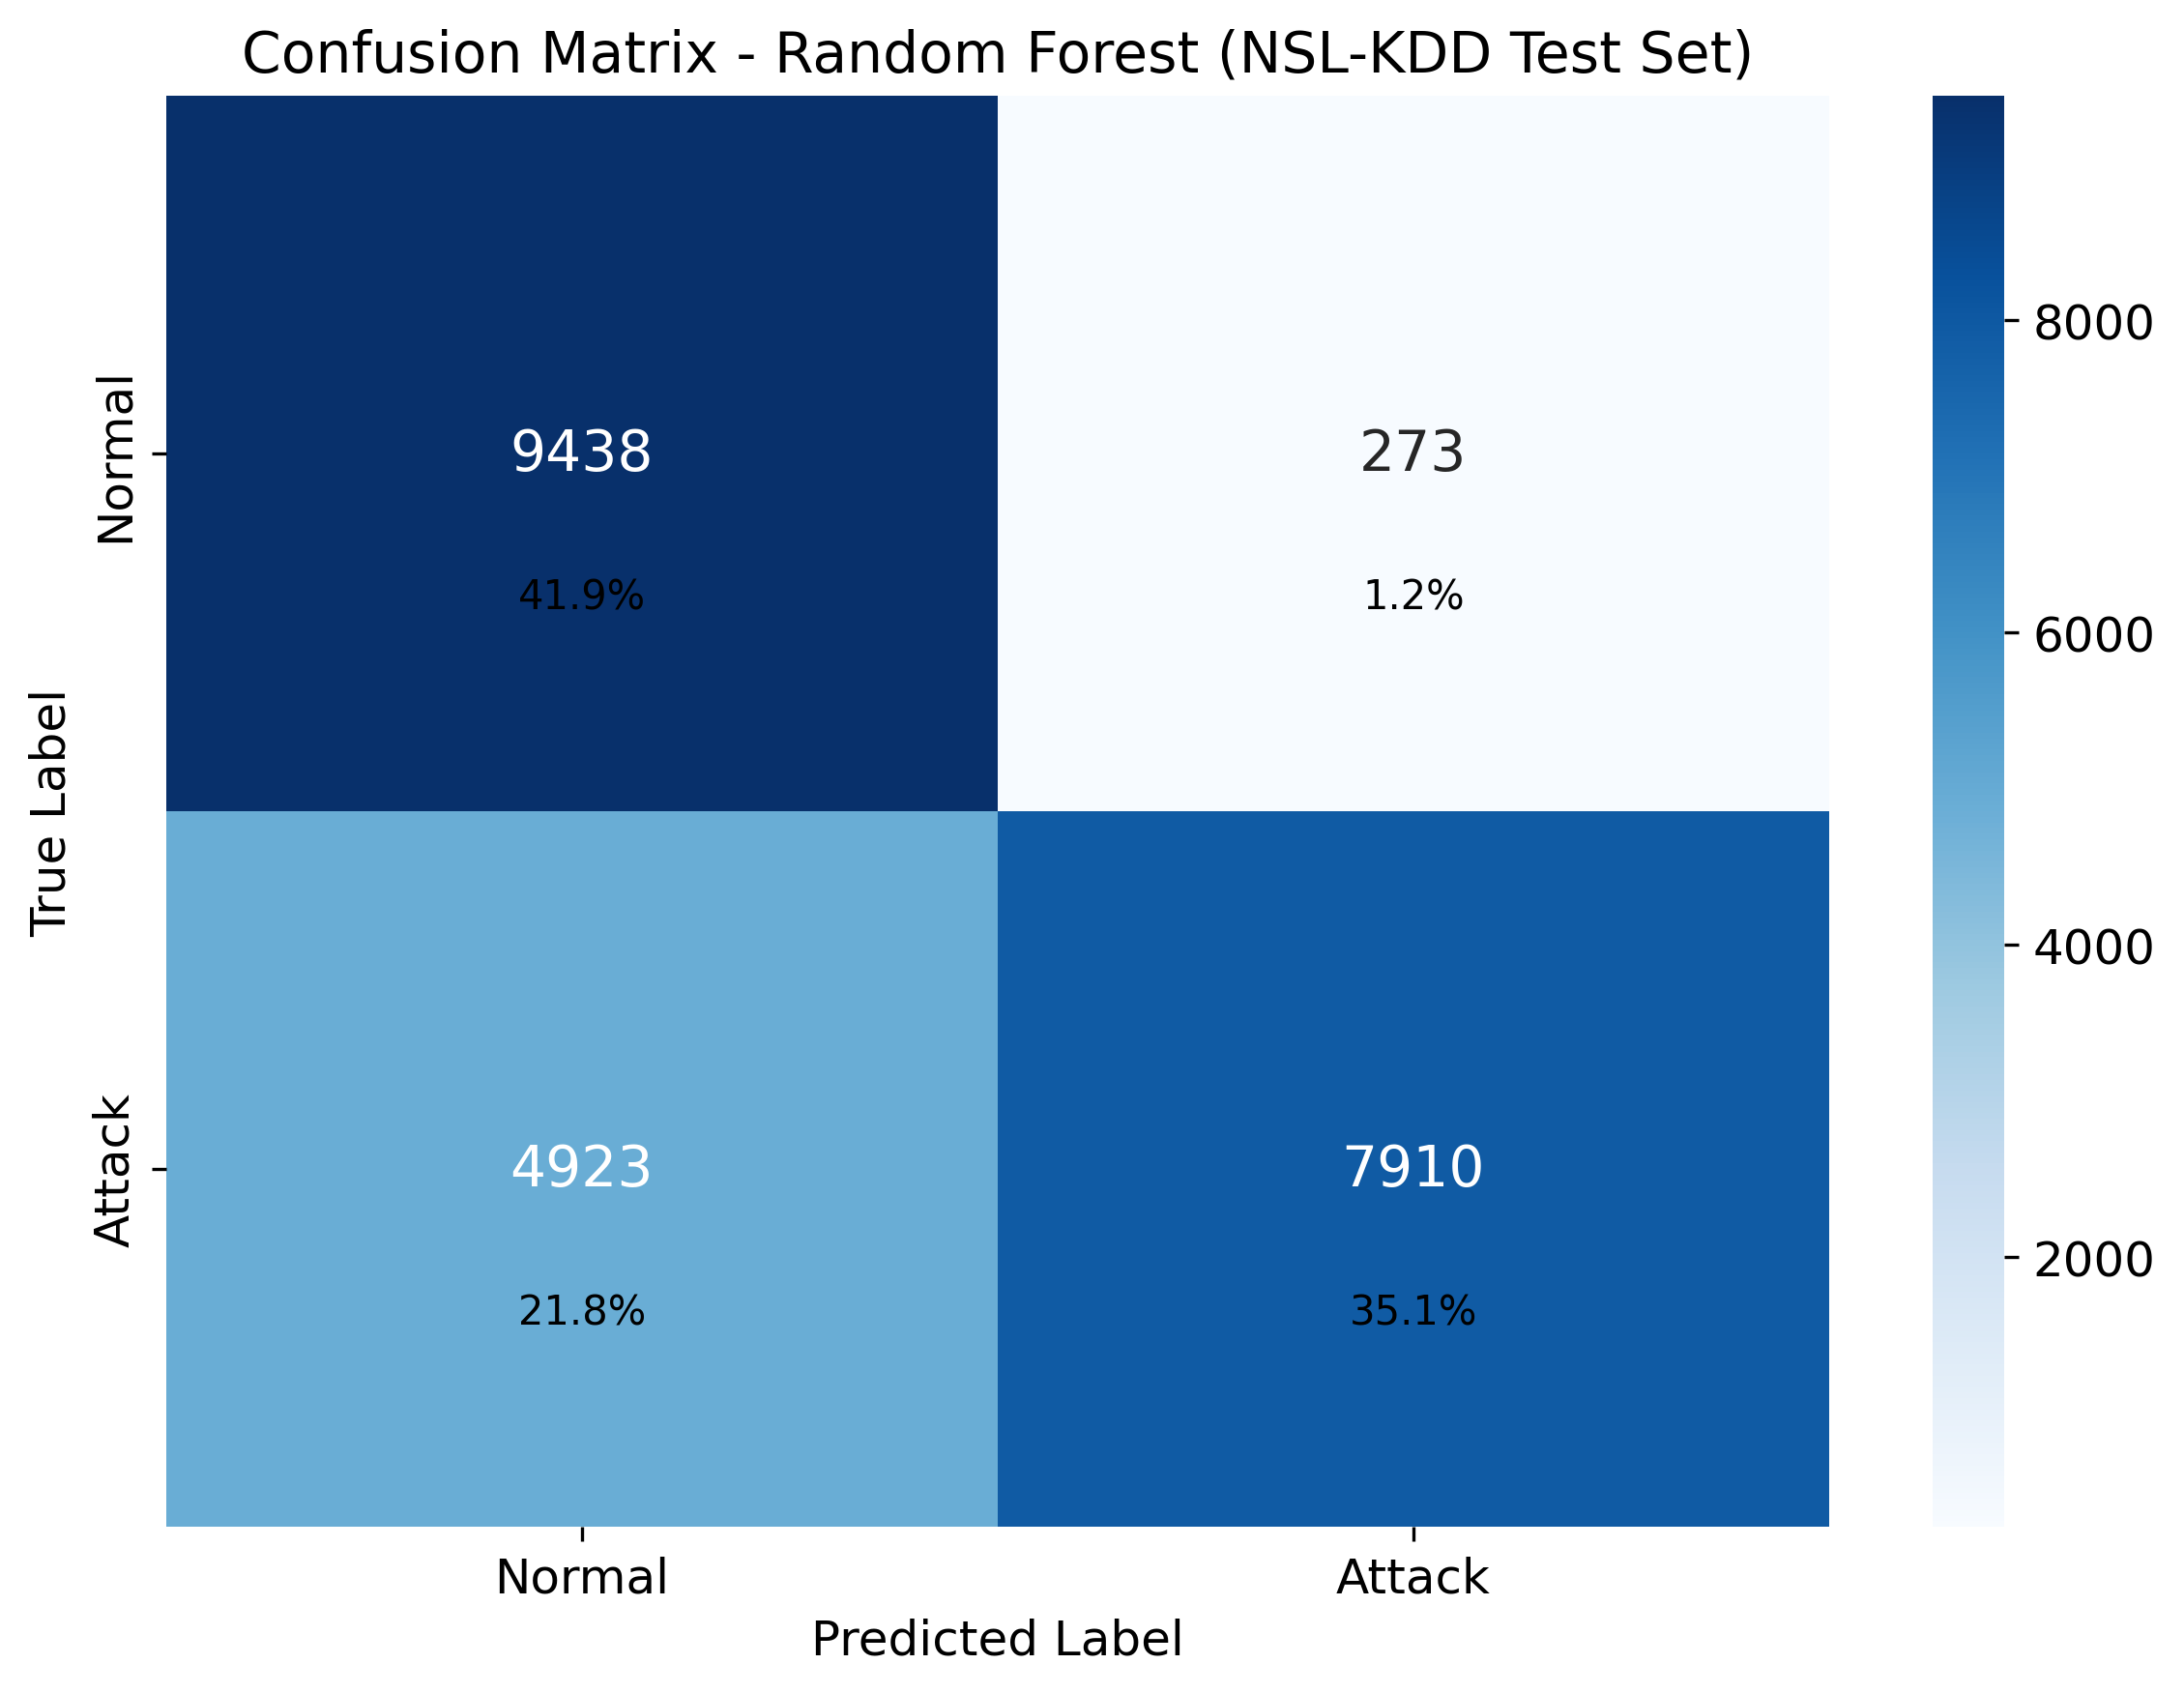

✅ Figure 2 saved!


In [4]:
# ============================================
# CELL 4: Figure 2 - Confusion Matrix (Best Model)
# ============================================
print("\n📊 Generating Figure 2: Confusion Matrix...")

# Get predictions from best model (Random Forest)
y_pred = rf_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            annot_kws={'size': 14})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Random Forest (NSL-KDD Test Set)', fontsize=14)

# Add percentages
total = np.sum(cm)
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / total * 100
        ax.text(j + 0.5, i + 0.7, f'{percentage:.1f}%',
               ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/report_fig2_confusion_matrix.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved!")


📊 Generating Figure 3: SHAP Summary Plot...


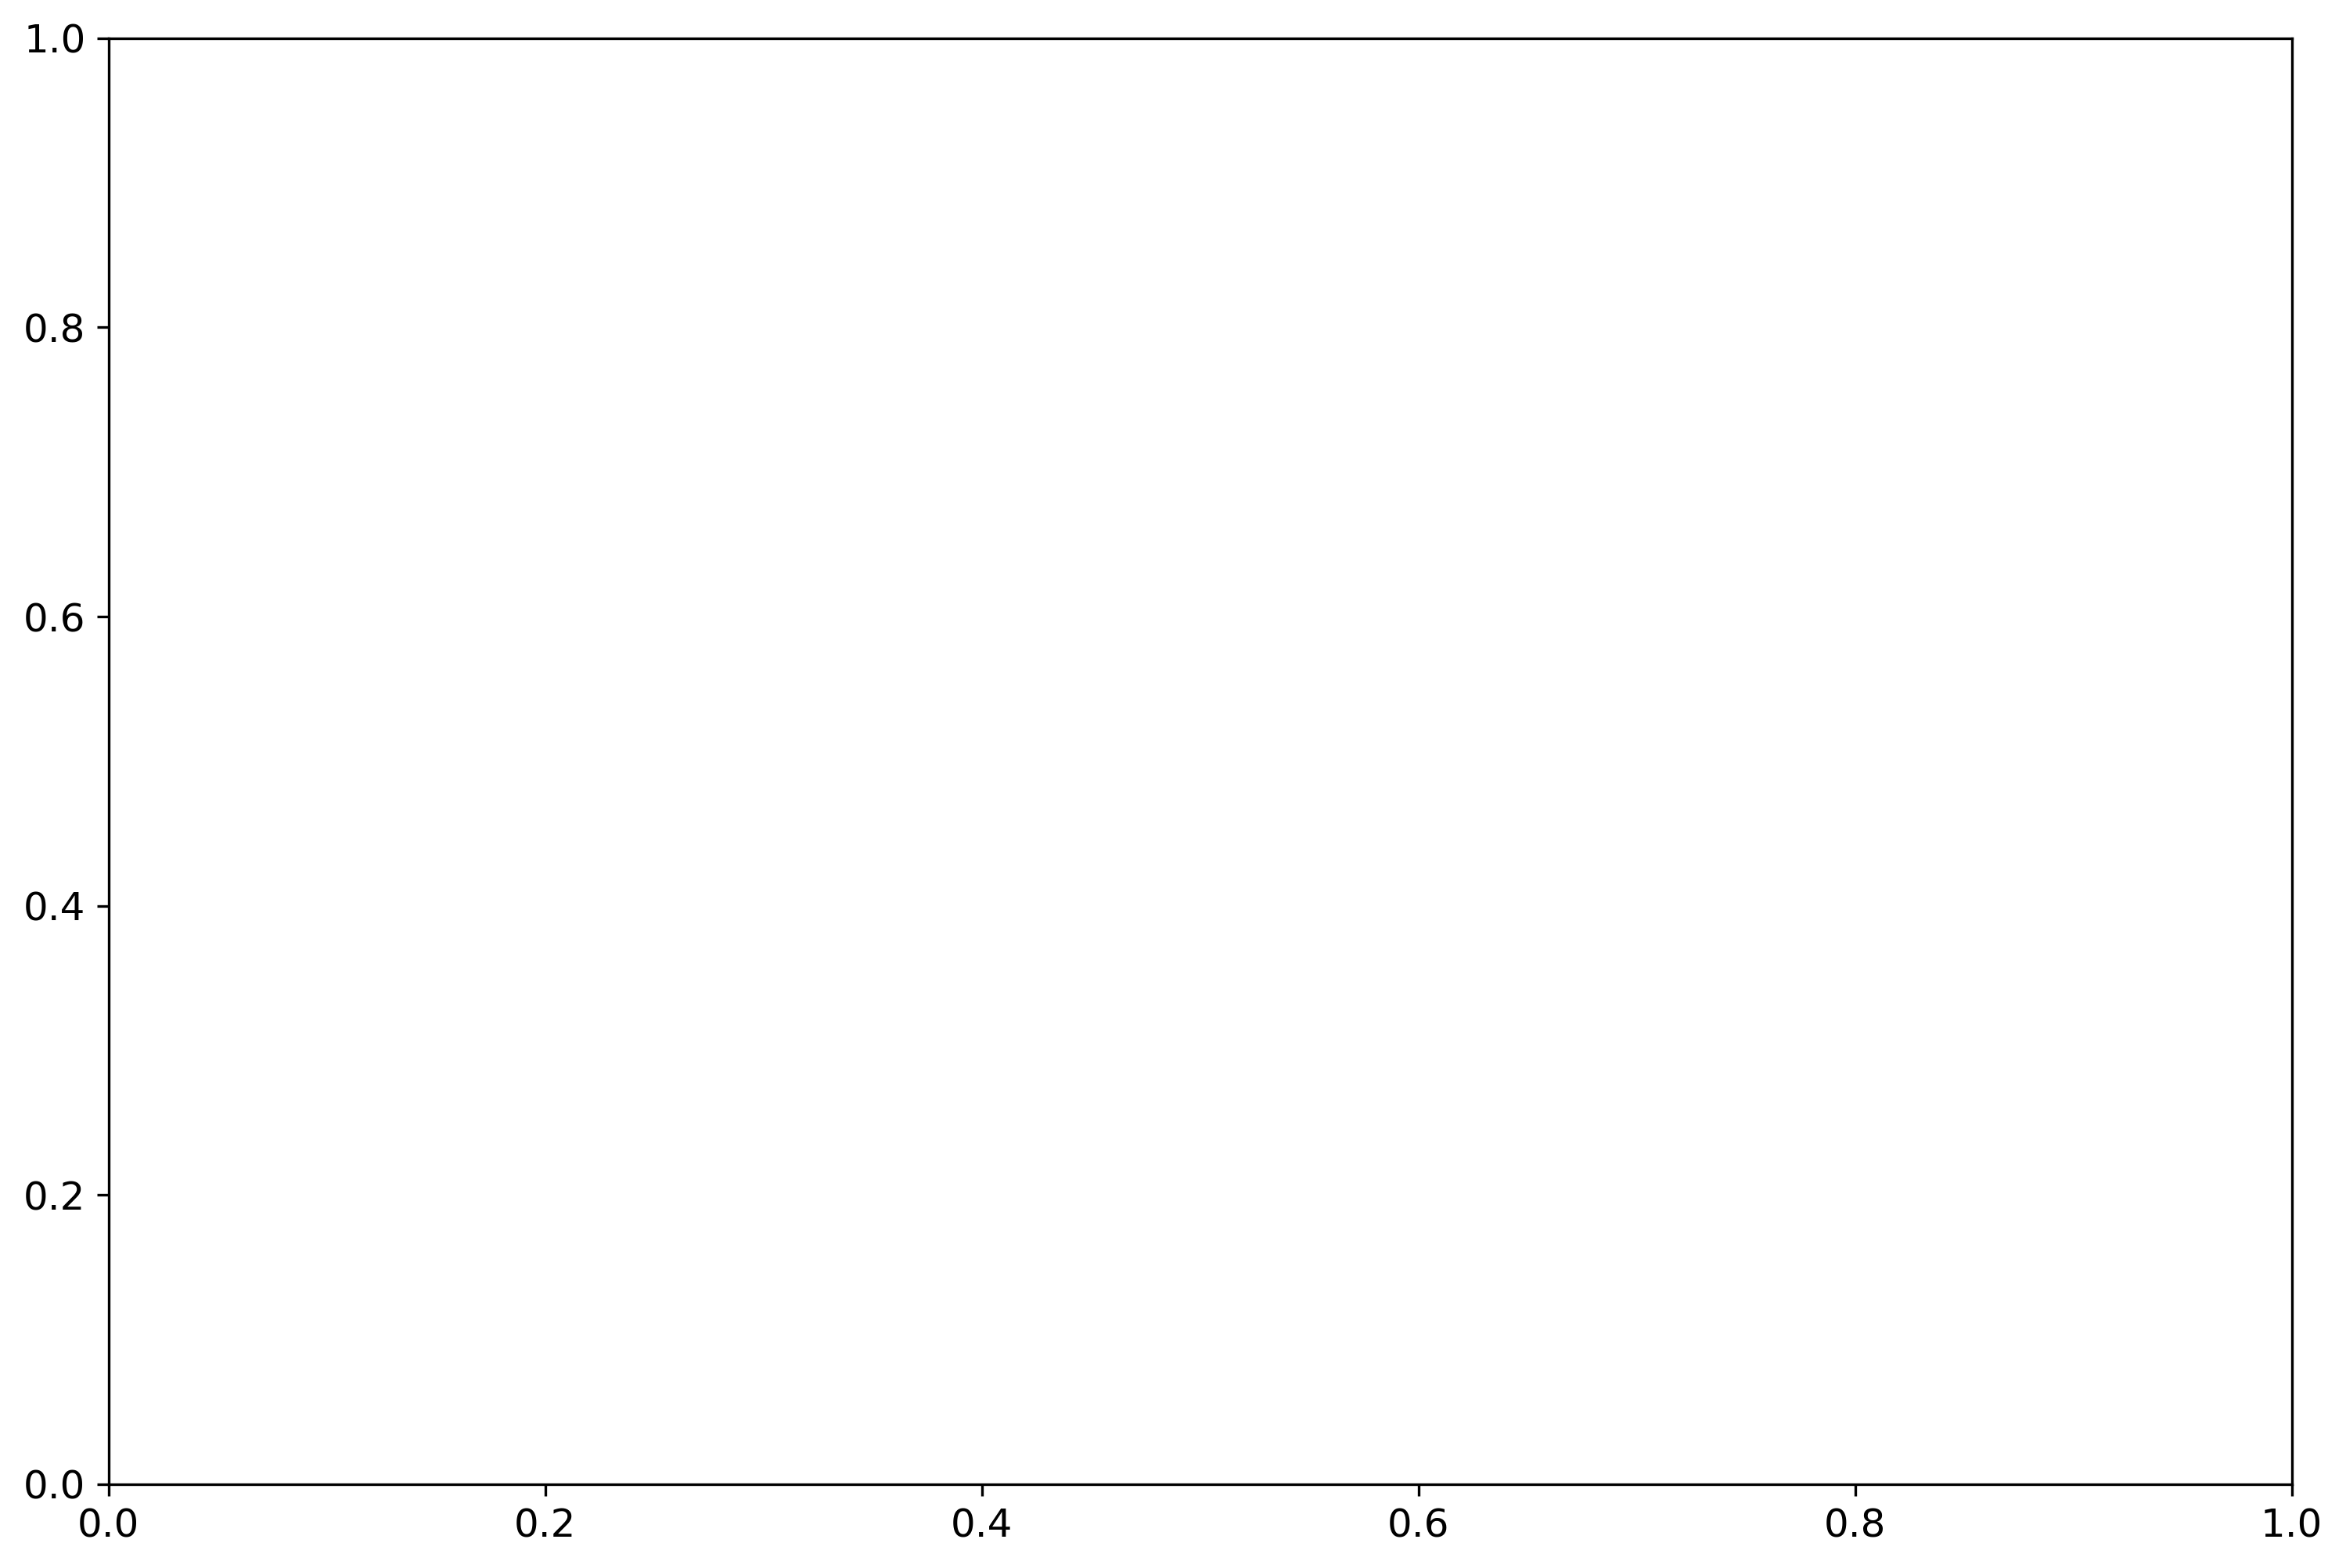

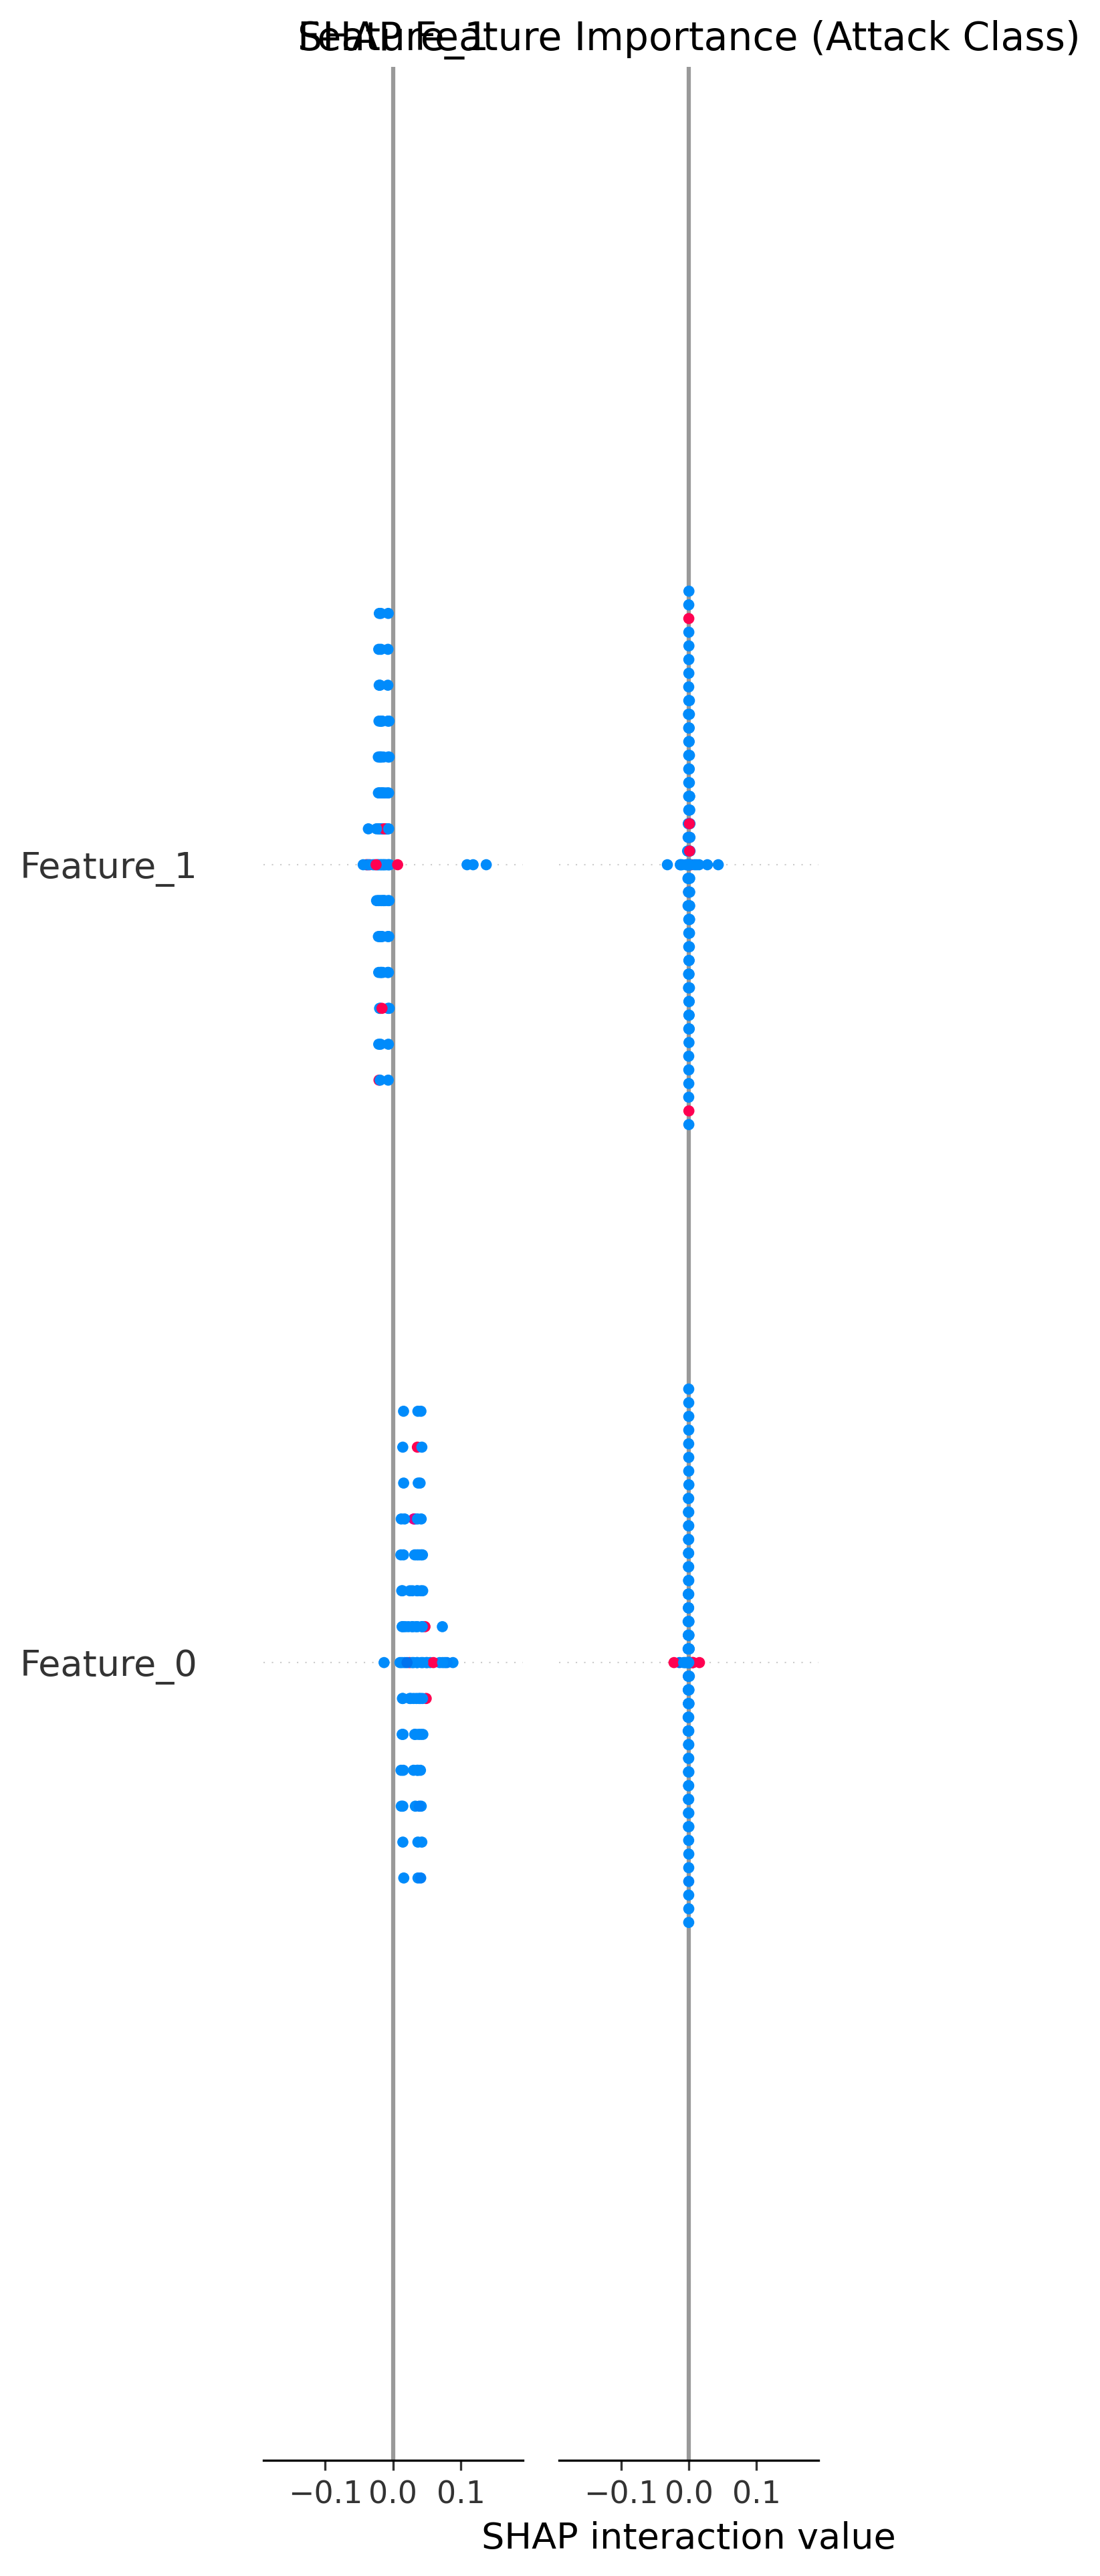

✅ Figure 3 saved!


In [5]:
# ============================================
# CELL 5: Figure 3 - SHAP Summary Plot
# ============================================
print("\n📊 Generating Figure 3: SHAP Summary Plot...")

import shap

# Get SHAP values for class 1 (attack)
if isinstance(shap_data['shap_values'], list):
    shap_vals = shap_data['shap_values'][1]
else:
    shap_vals = shap_data['shap_values']

# Get feature names
if 'feature_names' in shap_data:
    feature_names = shap_data['feature_names']
else:
    feature_names = [f'Feature_{i}' for i in range(shap_vals.shape[1])]

# Create summary plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_vals, shap_data['data'],
                  feature_names=feature_names,
                  show=False, max_display=15)
plt.title('SHAP Feature Importance (Attack Class)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/report_fig3_shap_summary.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved!")


📊 Generating Figure 4: SHAP vs LIME Agreement...


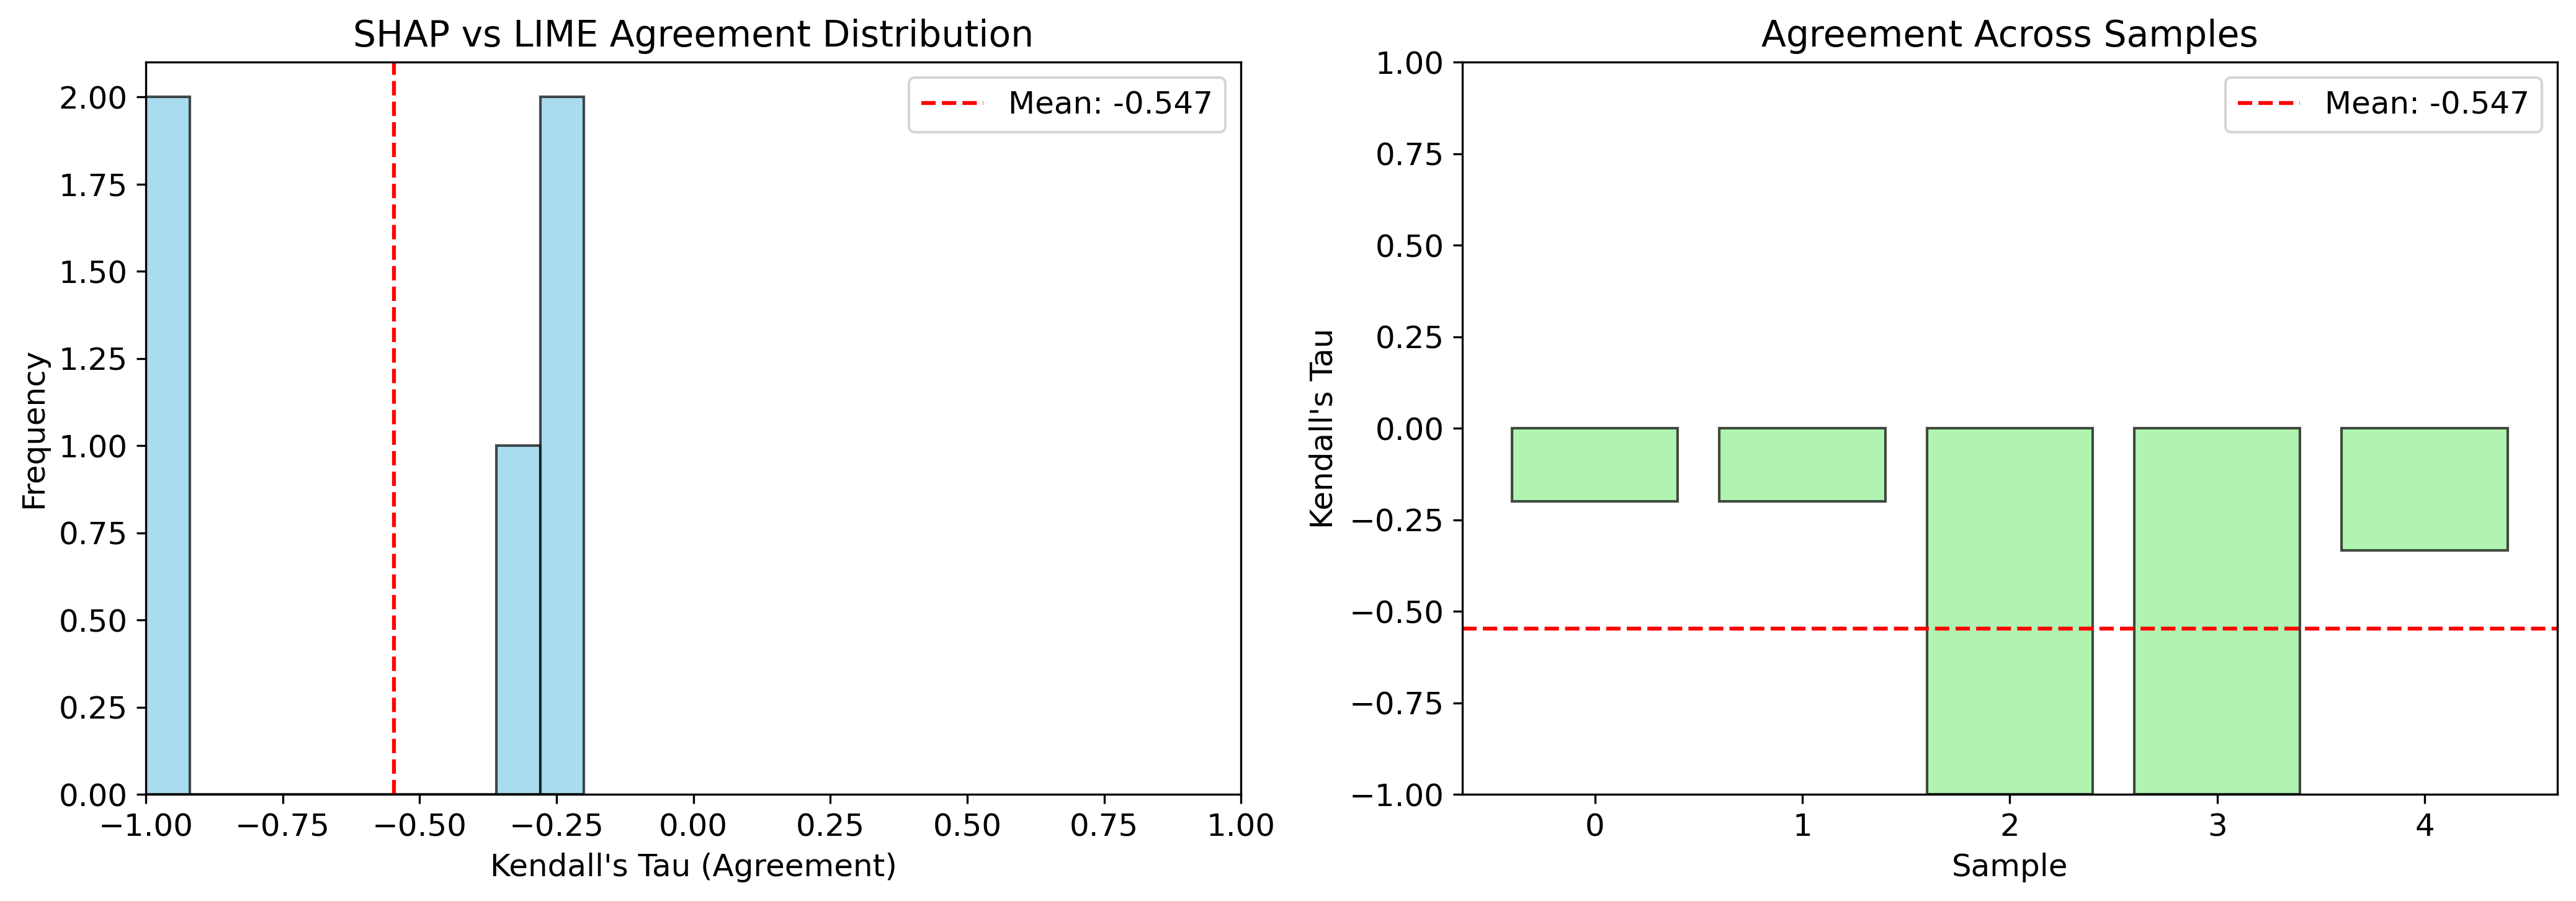

✅ Figure 4 saved!


In [6]:
# ============================================
# CELL 6: Figure 4 - SHAP vs LIME Agreement
# ============================================
print("\n📊 Generating Figure 4: SHAP vs LIME Agreement...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of agreement scores
axes[0].hist(xai_comparison['kendall_tau'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(xai_comparison['kendall_tau'].mean(), color='red', linestyle='--',
                label=f"Mean: {xai_comparison['kendall_tau'].mean():.3f}")
axes[0].set_xlabel("Kendall's Tau (Agreement)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("SHAP vs LIME Agreement Distribution")
axes[0].legend()
axes[0].set_xlim(-1, 1)

# Plot 2: Agreement by sample
axes[1].bar(xai_comparison['sample'], xai_comparison['kendall_tau'],
            color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axhline(xai_comparison['kendall_tau'].mean(), color='red', linestyle='--',
                label=f"Mean: {xai_comparison['kendall_tau'].mean():.3f}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Kendall's Tau")
axes[1].set_title("Agreement Across Samples")
axes[1].legend()
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/report_fig4_shap_vs_lime.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved!")


📊 Generating Figure 5: Dataset Comparison...


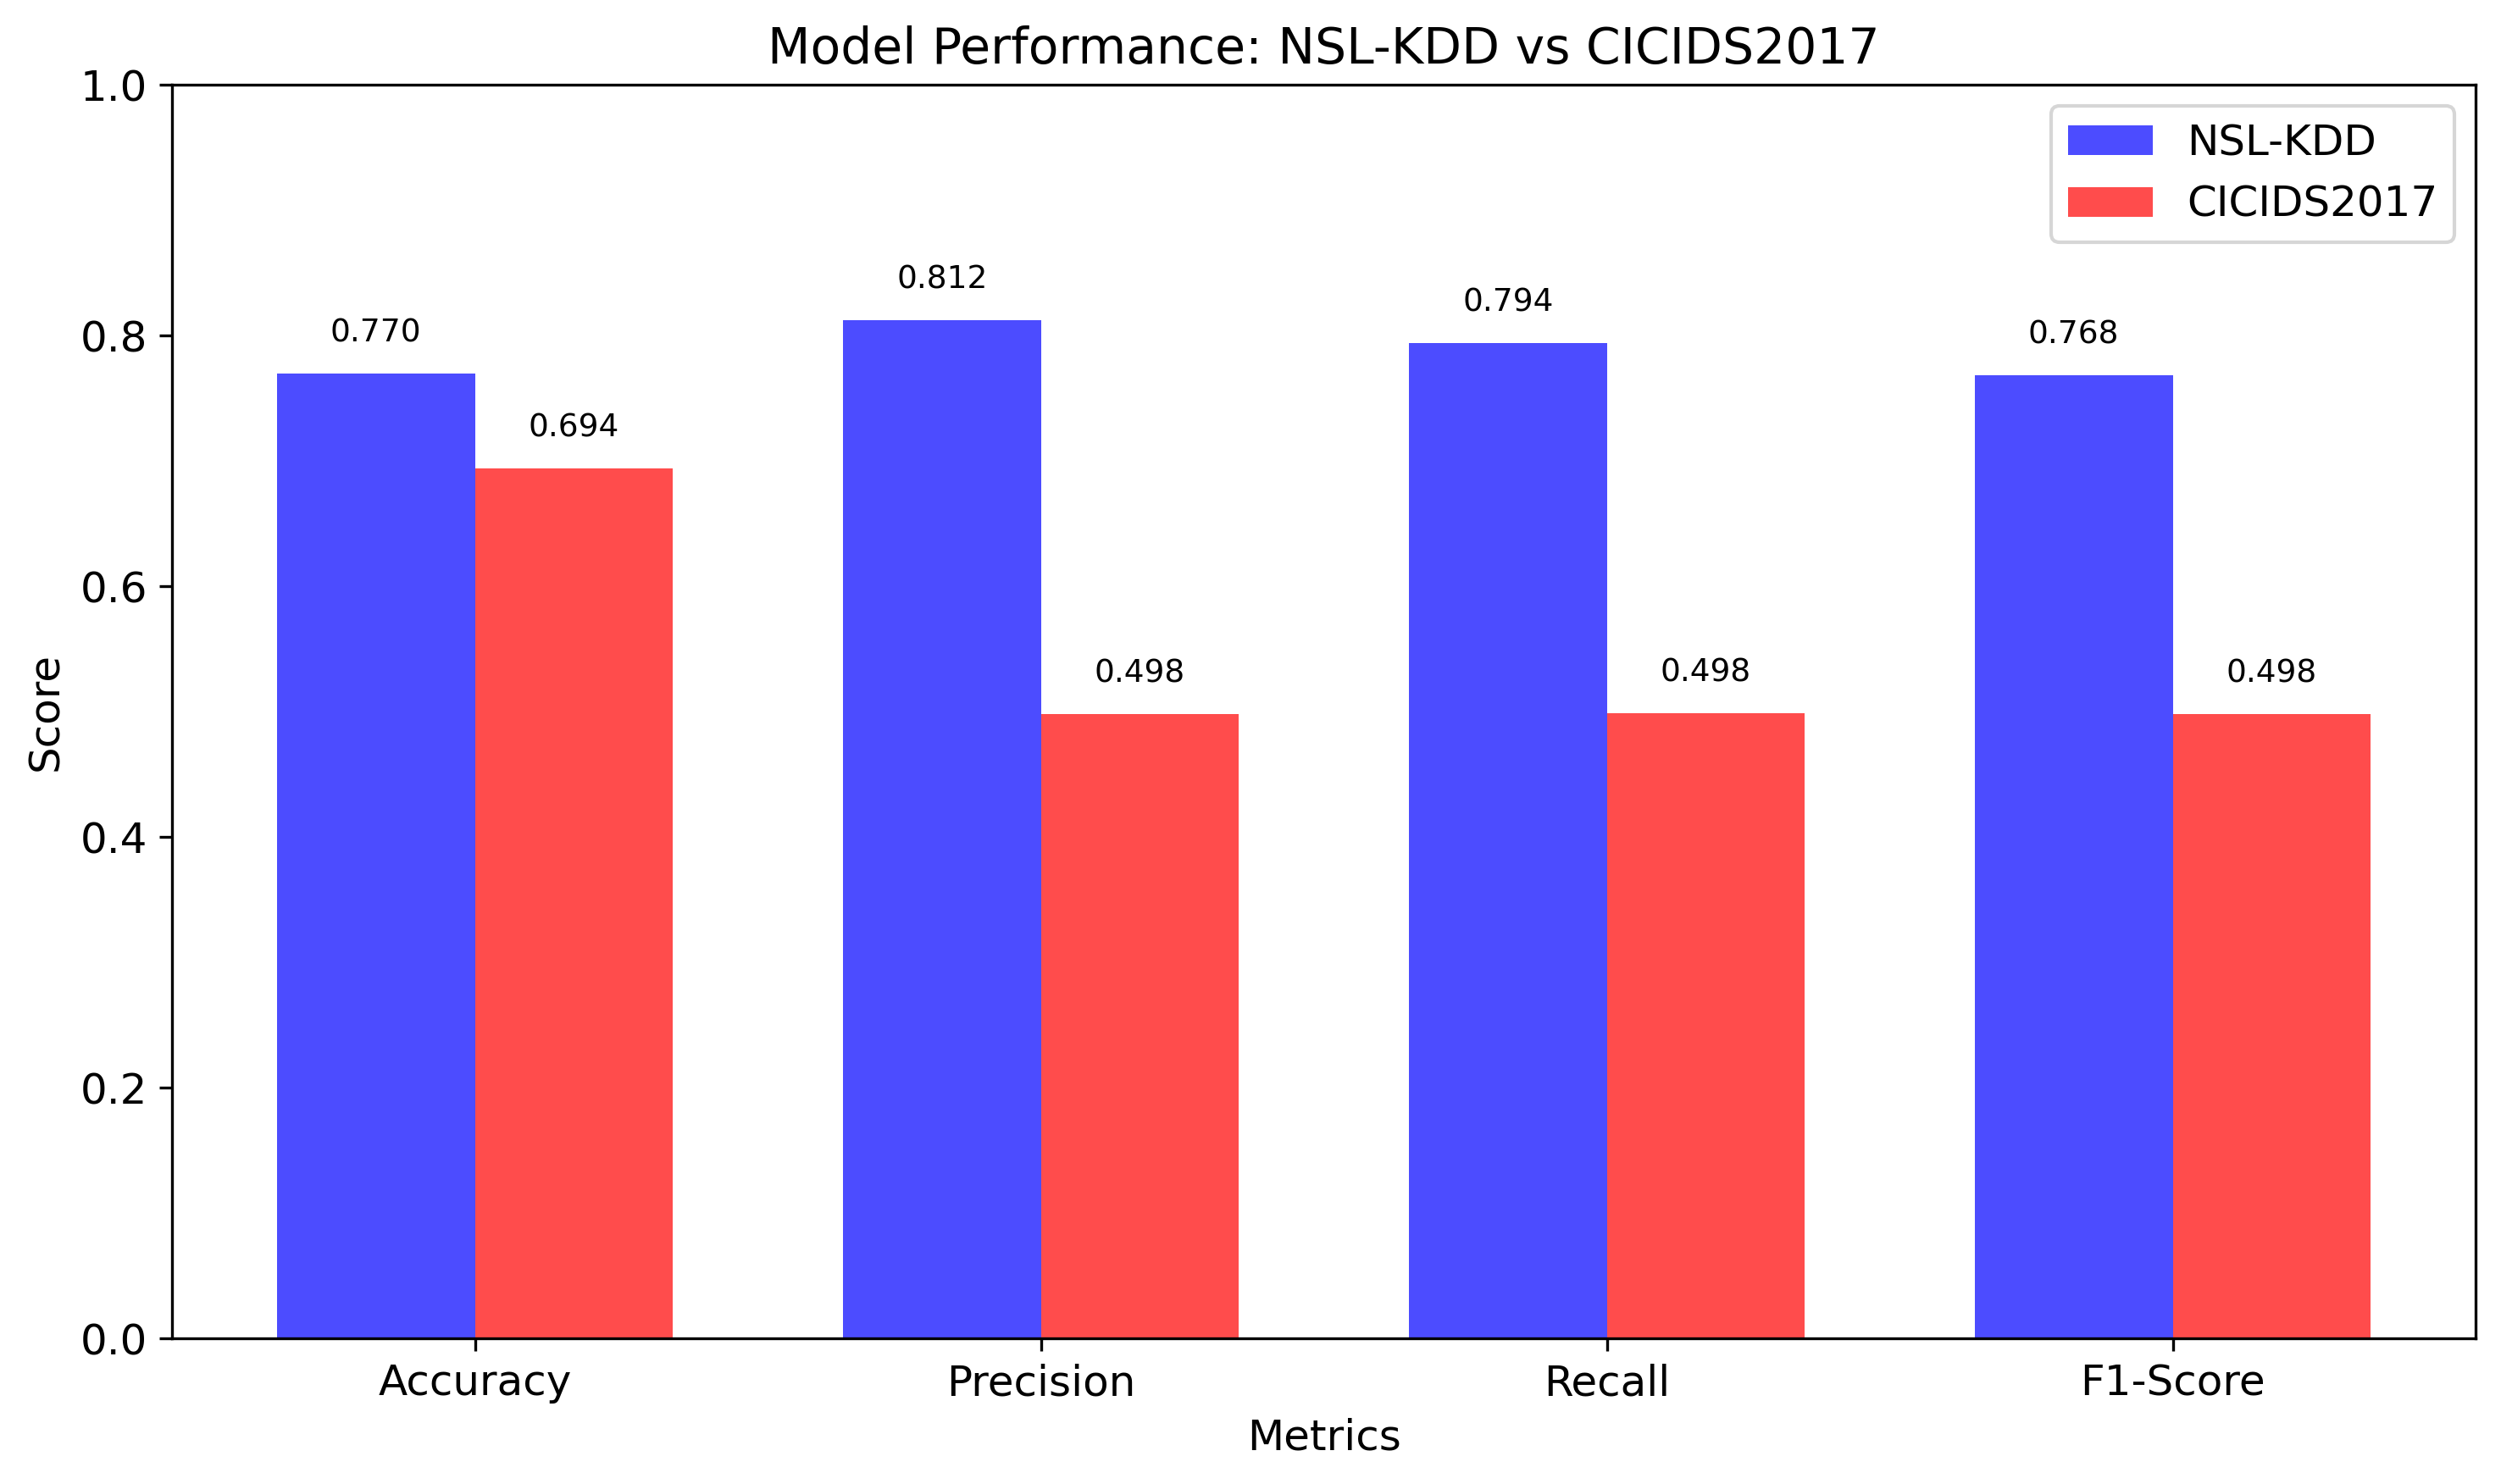

✅ Figure 5 saved!


In [7]:
# ============================================
# CELL 7: Figure 5 - NSL-KDD vs CICIDS2017
# ============================================
print("\n📊 Generating Figure 5: Dataset Comparison...")

fig, ax = plt.subplots(figsize=(10, 6))

metrics = dataset_comparison['Metric'].values
nsl_scores = dataset_comparison['NSL-KDD'].values
cicids_scores = dataset_comparison['CICIDS2017'].values

x = np.arange(len(metrics))
width = 0.35

ax.bar(x - width/2, nsl_scores, width, label='NSL-KDD', color='blue', alpha=0.7)
ax.bar(x + width/2, cicids_scores, width, label='CICIDS2017', color='red', alpha=0.7)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance: NSL-KDD vs CICIDS2017')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for i, (nsl, cicids) in enumerate(zip(nsl_scores, cicids_scores)):
    ax.text(i - width/2, nsl + 0.02, f'{nsl:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, cicids + 0.02, f'{cicids:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/report_fig5_dataset_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 5 saved!")


📊 Generating Figure 6: ROC Curve...


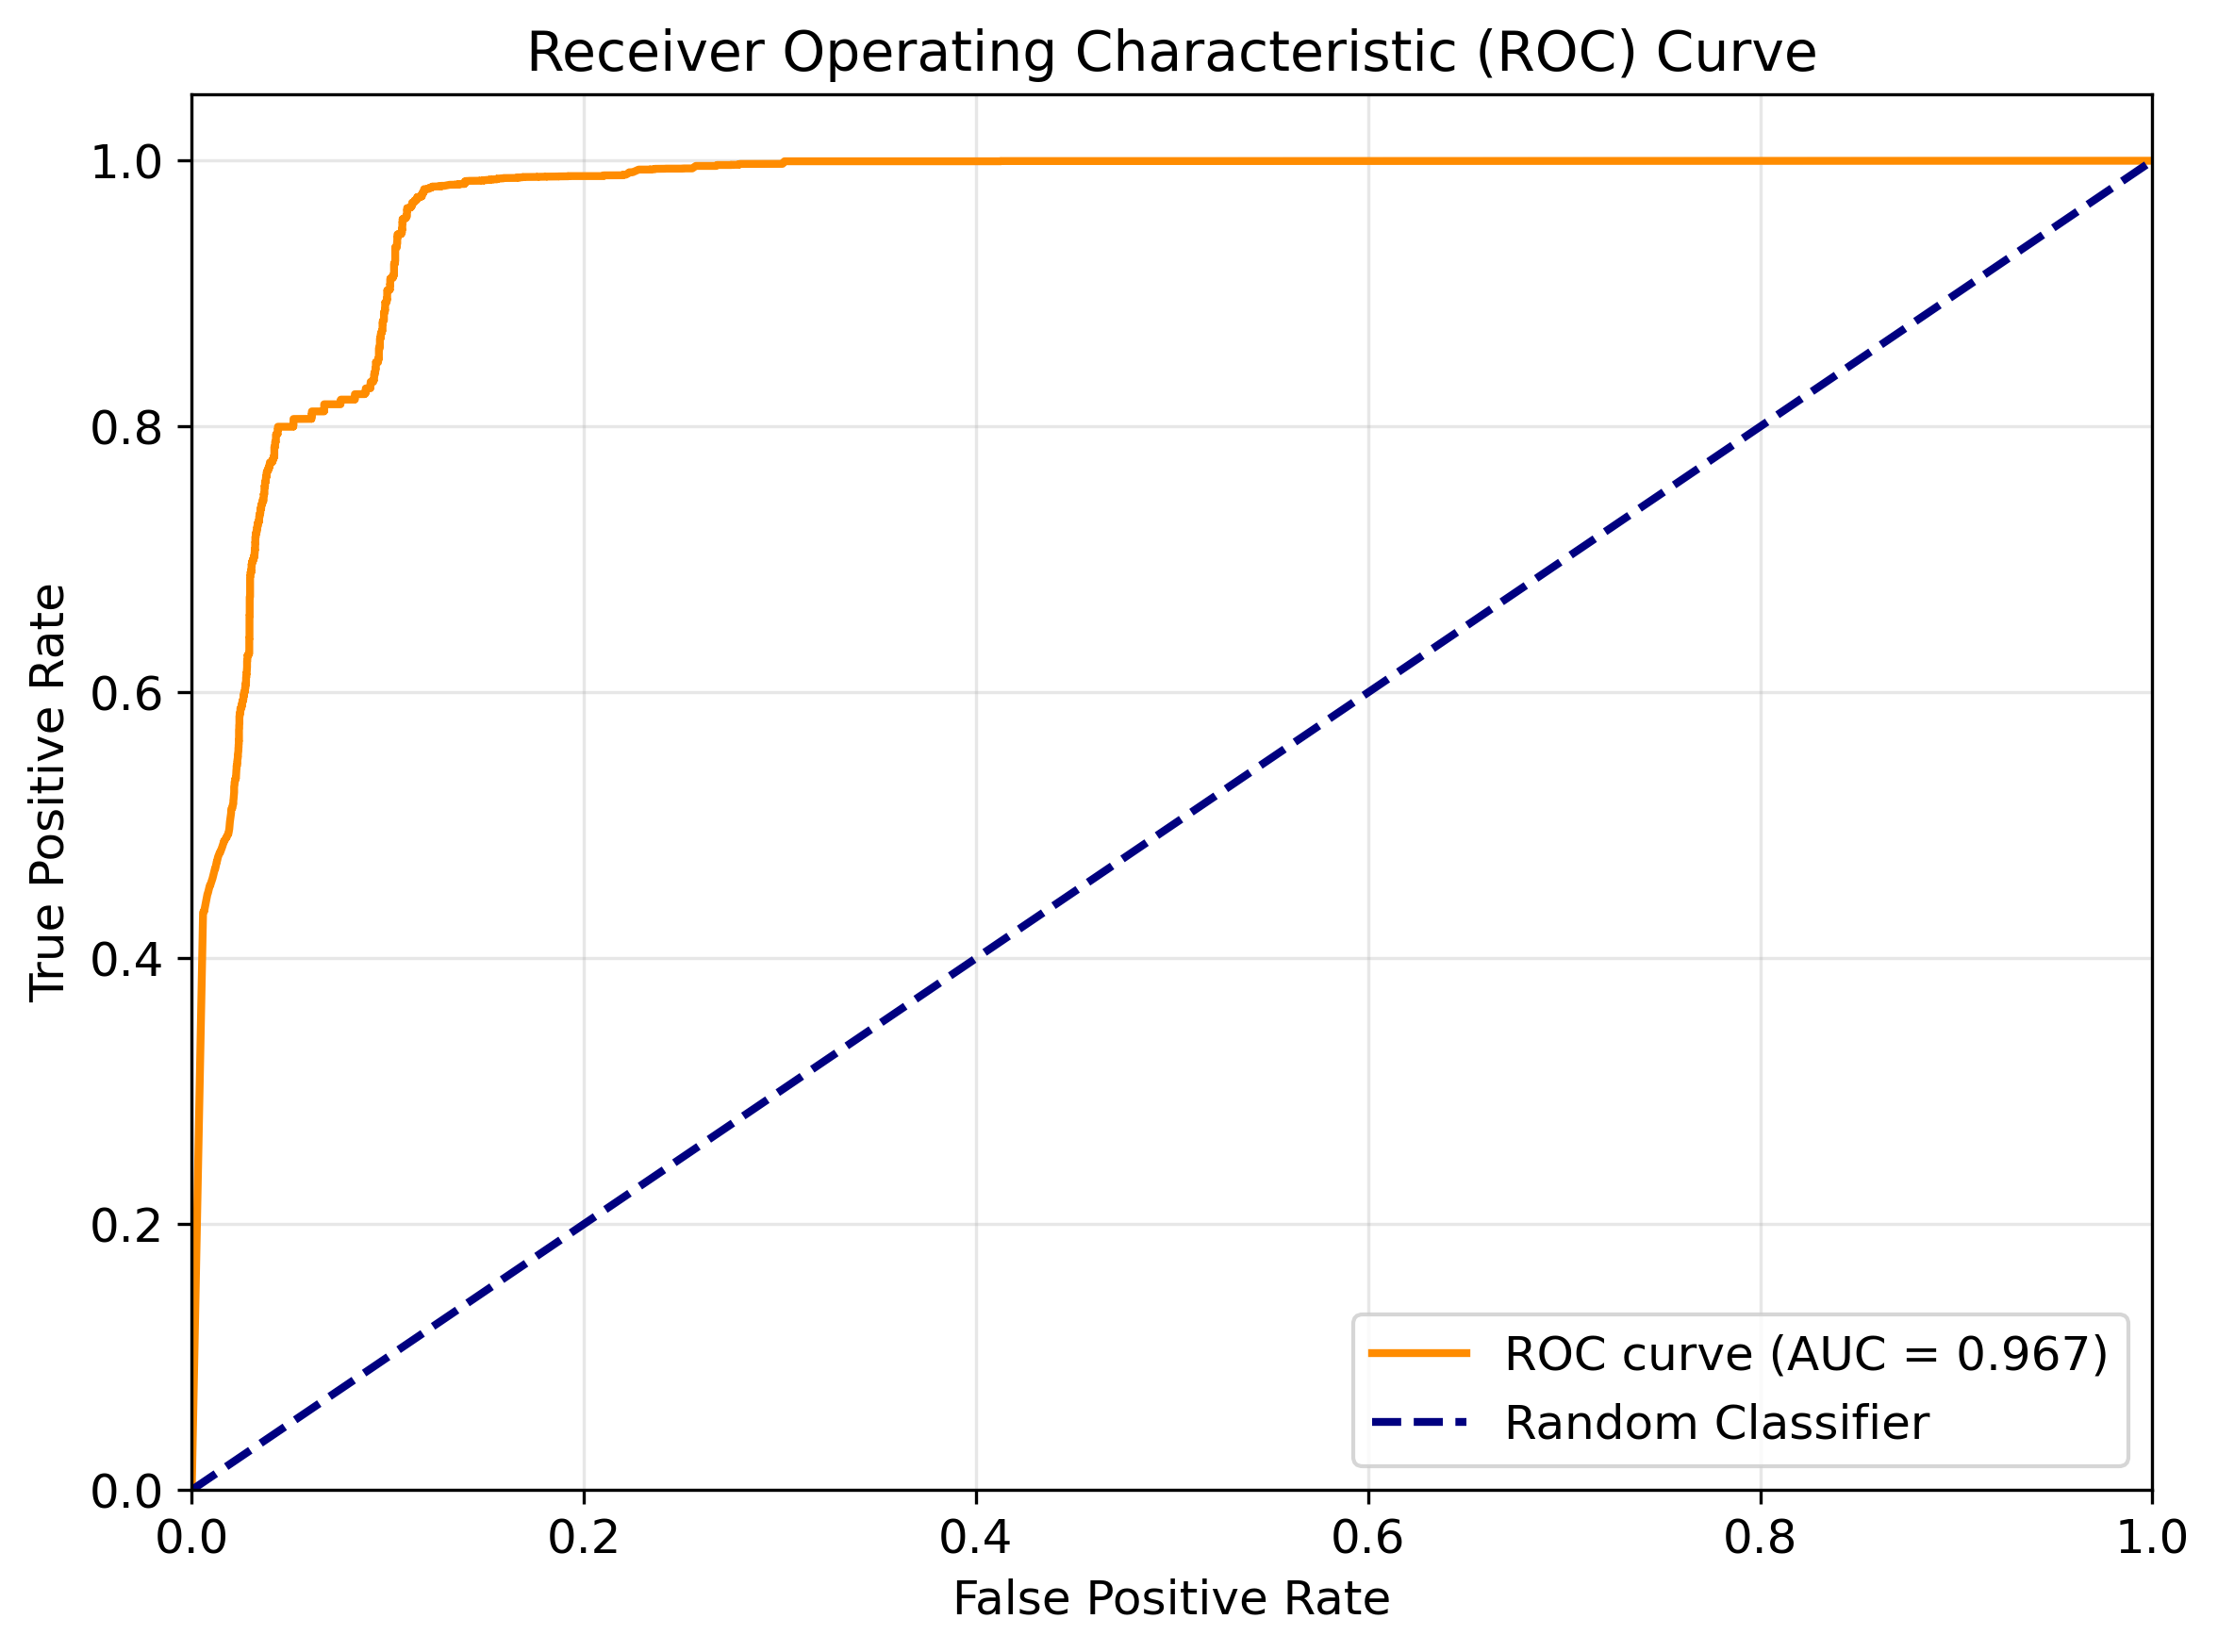

✅ Figure 6 saved!


In [8]:
# ============================================
# CELL 8: Figure 6 - ROC Curve
# ============================================
print("\n📊 Generating Figure 6: ROC Curve...")

# Get prediction probabilities
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/report_fig6_roc_curve.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 6 saved!")


📊 Generating Figure 7: Training Time Comparison...


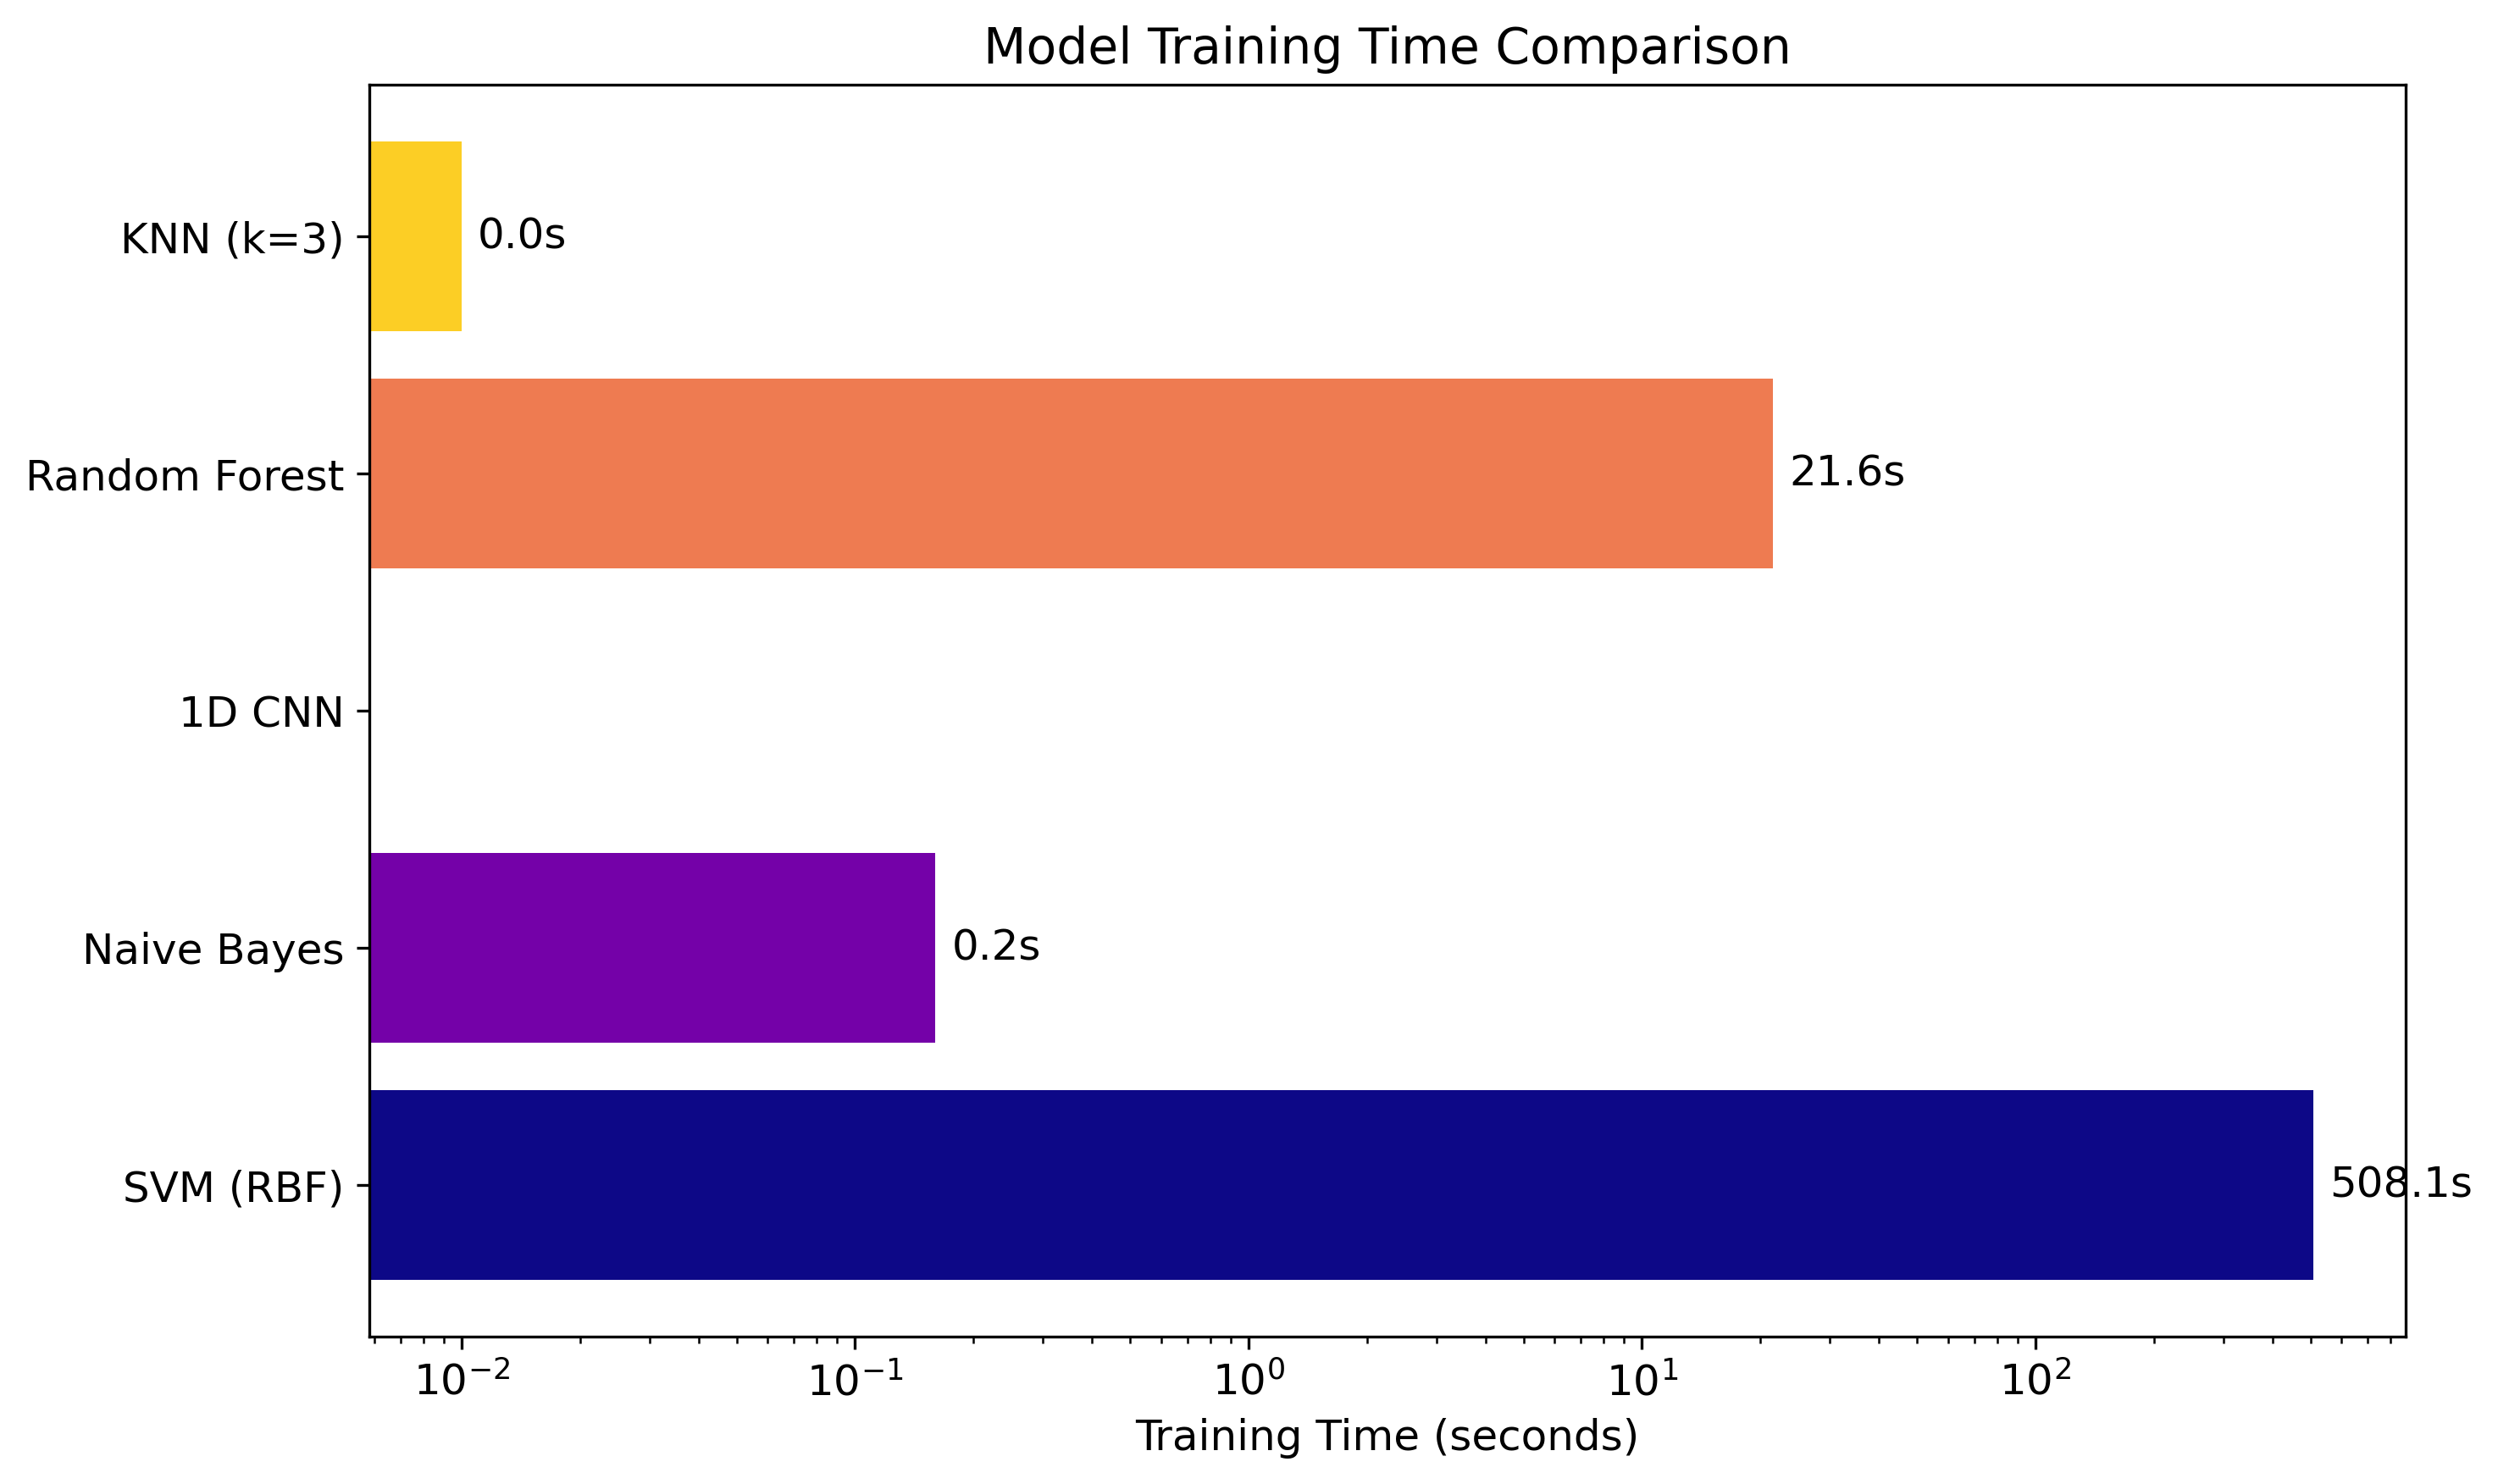

✅ Figure 7 saved!


In [9]:
# ============================================
# CELL 9: Figure 7 - Training Time Comparison
# ============================================
print("\n📊 Generating Figure 7: Training Time Comparison...")

fig, ax = plt.subplots(figsize=(10, 6))

models = model_comparison['model'].values
times = model_comparison['train_time'].values

# Handle CNN which might have 'N/A'
times_numeric = []
for t in times:
    if isinstance(t, (int, float)):
        times_numeric.append(t)
    else:
        times_numeric.append(1200)  # Approximate CNN time

colors = plt.cm.plasma(np.linspace(0, 0.9, len(models)))
bars = ax.barh(models, times_numeric, color=colors)
ax.set_xlabel('Training Time (seconds)')
ax.set_title('Model Training Time Comparison')
ax.set_xscale('log')  # Log scale because times vary widely

# Add value labels
for bar, time in zip(bars, times_numeric):
    ax.text(time * 1.1, bar.get_y() + bar.get_height()/2,
            f'{time:.1f}s', va='center')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/report_fig7_training_time.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 7 saved!")

In [10]:
# ============================================
# CELL 10: Summary Table for Report
# ============================================
print("\n📊 Generating Summary Table...")

# Create summary dataframe
summary = pd.DataFrame({
    'Metric': ['Best Model', 'Best F1-Score', 'SHAP vs LIME Agreement',
               'NSL-KDD F1', 'CICIDS2017 F1', 'AUC Score'],
    'Value': [
        model_comparison.loc[model_comparison['test_f1'].idxmax(), 'model'],
        f"{model_comparison['test_f1'].max():.4f}",
        f"{xai_comparison['kendall_tau'].mean():.4f} ± {xai_comparison['kendall_tau'].std():.4f}",
        f"{dataset_comparison['NSL-KDD'].iloc[3]:.4f}",  # F1 is 4th row
        f"{dataset_comparison['CICIDS2017'].iloc[3]:.4f}",
        f"{roc_auc:.4f}"
    ]
})

print("\n📋 REPORT SUMMARY TABLE")
print("=" * 60)
print(summary.to_string(index=False))
print("=" * 60)

# Save summary
summary.to_csv('/content/drive/MyDrive/xai-ids/results/metrics/report_summary.csv', index=False)
print("\n✅ Summary saved to: results/metrics/report_summary.csv")


📊 Generating Summary Table...

📋 REPORT SUMMARY TABLE
                Metric            Value
            Best Model        SVM (RBF)
         Best F1-Score           0.7813
SHAP vs LIME Agreement -0.5467 ± 0.4174
            NSL-KDD F1           0.7685
         CICIDS2017 F1           0.4980
             AUC Score           0.9674

✅ Summary saved to: results/metrics/report_summary.csv


In [11]:
# ============================================
# CELL 11: List All Generated Figures
# ============================================
print("\n📁 ALL REPORT FIGURES GENERATED:")
print("=" * 60)

!ls -la "/content/drive/MyDrive/xai-ids/results/figures/" | grep report_fig

print("\n" + "=" * 60)
print("✅ FIGURES READY FOR YOUR REPORT!")
print("=" * 60)
print("""
Location: /content/drive/MyDrive/xai-ids/results/figures/

Figure 1: report_fig1_model_comparison.png
Figure 2: report_fig2_confusion_matrix.png
Figure 3: report_fig3_shap_summary.png
Figure 4: report_fig4_shap_vs_lime.png
Figure 5: report_fig5_dataset_comparison.png
Figure 6: report_fig6_roc_curve.png
Figure 7: report_fig7_training_time.png
""")


📁 ALL REPORT FIGURES GENERATED:
-rw------- 1 root root  203482 Mar 11 23:17 report_fig1_model_comparison.png
-rw------- 1 root root  131009 Mar 11 23:17 report_fig2_confusion_matrix.png
-rw------- 1 root root  146240 Mar 11 23:17 report_fig3_shap_summary.png
-rw------- 1 root root  175876 Mar 11 23:18 report_fig4_shap_vs_lime.png
-rw------- 1 root root  122421 Mar 11 23:18 report_fig5_dataset_comparison.png
-rw------- 1 root root  169222 Mar 11 23:18 report_fig6_roc_curve.png
-rw------- 1 root root  109505 Mar 11 23:18 report_fig7_training_time.png

✅ FIGURES READY FOR YOUR REPORT!

Location: /content/drive/MyDrive/xai-ids/results/figures/

Figure 1: report_fig1_model_comparison.png
Figure 2: report_fig2_confusion_matrix.png
Figure 3: report_fig3_shap_summary.png
Figure 4: report_fig4_shap_vs_lime.png
Figure 5: report_fig5_dataset_comparison.png
Figure 6: report_fig6_roc_curve.png
Figure 7: report_fig7_training_time.png

